# Random Forests and Bagging Ensembles

---

**Topics covered in this session:**
1. Bootstrap Sampling
2. Bagging Intuition
3. RandomForestClassifier and RandomForestRegressor
4. Out-of-Bag (OOB) Error
5. Random Forest Feature Importance
6. Permutation Importance
7. Key Hyperparameters: n_estimators, max_features, max_depth

---

---
## Section 0 -- Setup and Imports


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score,
                              ConfusionMatrixDisplay, mean_squared_error, r2_score)
from sklearn.inspection import permutation_importance
from sklearn.datasets import make_regression

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All imports successful.')
import sklearn; print(f'Sklearn version: {sklearn.__version__}')


All imports successful.
Sklearn version: 1.9.0


---
## Section 1 -- The Dataset

We continue with the same credit risk dataset from Session 40.
This is intentional: you will be able to directly compare a single Decision Tree
against a Random Forest on identical data, which is the clearest way to see
what ensembling actually buys you.

The target variable is `default` (1 = loan defaulted, 0 = loan repaid).


In [26]:
np.random.seed(42)
N = 2000

credit_score    = np.random.randint(300, 851, N)
income          = np.random.normal(65000, 20000, N).clip(20000, 200000)
loan_amount     = np.random.normal(15000, 7000, N).clip(1000, 60000)
age             = np.random.randint(21, 65, N)
months_employed = np.random.randint(0, 300, N)
num_credit_lines= np.random.randint(1, 10, N)
interest_rate   = np.random.uniform(5, 25, N).round(2)
num_loans       = np.random.randint(0, 5, N)
has_mortgage    = np.random.randint(0, 2, N)
has_dependents  = np.random.randint(0, 2, N)
has_cosigner    = np.random.randint(0, 2, N)
loan_purpose    = np.random.choice(['education','home','business','auto','personal'], N)
loan_to_income  = (loan_amount / income).round(4)

log_odds = (
    -4.0
    - 0.006 * credit_score
    + 2.5   * loan_to_income
    + 0.03  * interest_rate
    - 0.003 * months_employed
    + 0.3   * num_loans
    - 0.5   * has_cosigner
    + 0.2   * has_dependents
)
prob_default = 1 / (1 + np.exp(-log_odds))
default = (np.random.rand(N) < prob_default).astype(int)

df = pd.DataFrame({
    'age': age, 'income': income.round(0), 'loan_amount': loan_amount.round(0),
    'loan_to_income': loan_to_income, 'credit_score': credit_score,
    'months_employed': months_employed, 'num_credit_lines': num_credit_lines,
    'interest_rate': interest_rate, 'num_loans': num_loans,
    'has_mortgage': has_mortgage, 'has_dependents': has_dependents,
    'loan_purpose': loan_purpose, 'has_cosigner': has_cosigner,
    'default': default
})
df = pd.get_dummies(df, columns=['loan_purpose'], drop_first=False)

FEATURES = [c for c in df.columns if c != 'default']
X = df[FEATURES]
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} rows, {X_train.shape[1]} features')
print(f'Test set     : {X_test.shape[0]} rows')
print(f'Default rate : {y.mean():.1%}')


Training set : 1600 rows, 17 features
Test set     : 400 rows
Default rate : 0.4%


In [27]:
df

,age,income,loan_amount,loan_to_income,credit_score,months_employed,num_credit_lines,interest_rate,num_loans,has_mortgage,has_dependents,has_cosigner,default,loan_purpose_auto,loan_purpose_business,loan_purpose_education,loan_purpose_home,loan_purpose_personal
0,48,90795.0,15132.0,0.1667,402,190,1,5.42,1,0,1,0,0,False,False,False,True,False
1,39,78464.0,6798.0,0.0866,735,169,1,17.57,2,0,1,1,0,False,True,False,False,False
2,44,62231.0,26870.0,0.4318,570,44,1,17.59,3,0,0,0,0,True,False,False,False,False
3,39,40514.0,28281.0,0.6981,406,13,4,24.74,2,0,0,0,0,True,False,False,False,False
4,33,60820.0,16097.0,0.2647,371,230,1,12.96,4,1,1,1,0,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,56,53788.0,7243.0,0.1347,318,287,1,11.12,3,0,0,0,0,False,False,True,False,False
1996,58,20000.0,21832.0,1.0916,322,123,8,22.70,0,1,1,1,0,False,False,True,False,False
1997,60,106059.0,24796.0,0.2338,712,282,8,19.48,2,0,1,0,0,True,False,False,False,False
1998,49,86775.0,10599.0,0.1221,329,179,4,18.39,0,1,1,0,0,False,False,False,False,True


---
## Section 2 -- The Problem with a Single Decision Tree

Before introducing Random Forests, we need to understand precisely why a single
decision tree is not good enough.

### Variance vs Bias

Every machine learning model makes errors. Those errors come from two sources:

**Bias** is how wrong the model is on average -- how far off its predictions
are from the truth, regardless of which training set you use.
A model with high bias is too simple. It misses real patterns.

**Variance** is how much the model's predictions change when you train it on
different samples of data. A model with high variance is too sensitive --
it picks up noise in the training data and treats it as signal.

A fully grown decision tree has **low bias** (it can fit almost anything)
but **very high variance** (change the training data slightly and you get
a completely different tree).

### A concrete demonstration

Below we train 10 different decision trees, each on a slightly different
random sample of the training data. Watch how much the predictions vary.


In [28]:
# Train 10 decision trees on different random subsets of training data
# Watch how much the test accuracy varies across trees

np.random.seed(0)
n_trees  = 10
tree_accs = []
tree_preds = []

for i in range(n_trees):
    # Sample 80% of training data with replacement
    idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_sample = X_train.iloc[idx]
    y_sample = y_train.iloc[idx]

    clf = DecisionTreeClassifier(random_state=i)
    clf.fit(X_sample, y_sample)
    acc = clf.score(X_test, y_test)
    tree_accs.append(acc)
    tree_preds.append(clf.predict_proba(X_test)[:, 1])

print('Accuracy of 10 individual decision trees (each on a different data sample):')
for i, acc in enumerate(tree_accs):
    print(f'  Tree {i+1:2d}: {acc:.4f}')
print(f'  Mean  : {np.mean(tree_accs):.4f}')
print(f'  Std   : {np.std(tree_accs):.4f}  <-- this is the variance problem')

# Now average the predictions of all 10 trees
avg_proba = np.mean(tree_preds, axis=0)
avg_pred  = (avg_proba >= 0.5).astype(int)
from sklearn.metrics import accuracy_score
ensemble_acc = accuracy_score(y_test, avg_pred)
print(f'\nEnsemble of 10 trees (averaged): {ensemble_acc:.4f}')
print('The ensemble is more stable and usually more accurate than any individual tree.')


Accuracy of 10 individual decision trees (each on a different data sample):
  Tree  1: 0.9975
  Tree  2: 0.9875
  Tree  3: 0.9875
  Tree  4: 0.9925
  Tree  5: 0.9900
  Tree  6: 0.9925
  Tree  7: 0.9925
  Tree  8: 0.9975
  Tree  9: 0.9975
  Tree 10: 0.9825
  Mean  : 0.9918
  Std   : 0.0048  <-- this is the variance problem

Ensemble of 10 trees (averaged): 0.9975
The ensemble is more stable and usually more accurate than any individual tree.


---
## Section 3 -- Bootstrap Sampling

Bootstrap sampling is the foundational statistical technique that makes
bagging and Random Forests work. Understanding it precisely is important.

### Definition

Given a dataset of N samples, a **bootstrap sample** is created by:
1. Drawing N samples **with replacement** from the original dataset
2. The result has the same size N, but some rows appear multiple times
   and some rows are left out entirely

The key word is **with replacement** -- after you pick a row, you put it back
before picking the next one. This means the same row can be selected multiple times.

### What fraction of data is left out?

For large N, the probability that any specific row is **never** selected in
one bootstrap sample converges to:

$$P(\text{not selected}) = \left(1 - \frac{1}{N}\right)^N \to e^{-1} \approx 0.368$$

So roughly **36.8% of the original data** is left out of each bootstrap sample.
This left-out data is called the **Out-of-Bag (OOB) sample** -- we will use it
later to estimate model performance without a separate validation set.

### Why does this help?

Each bootstrap sample is a slightly different view of the data.
If you train a tree on each bootstrap sample, each tree is slightly different.
When you **average** many different trees, the variance cancels out
while the signal (true pattern) stays consistent.

This is the core intuition behind **bagging**.


In [29]:
# Demonstrating bootstrap sampling step by step

np.random.seed(42)
original = np.arange(10)   # a tiny dataset: indices 0 to 9
N = len(original)

bootstrap_samples = []
oob_samples       = []

print(f'Original dataset indices: {original.tolist()}')
print('-' * 60)

for trial in range(5):
    sample = np.random.choice(original, size=N, replace=True)
    oob    = np.setdiff1d(original, sample)
    bootstrap_samples.append(sample)
    oob_samples.append(oob)
    counts = {i: list(sample).count(i) for i in original if i in sample}
    print(f'Bootstrap {trial+1}: {sorted(sample.tolist())}  |  OOB: {sorted(oob.tolist())}')

print('-' * 60)
print()

# Verify the ~36.8% OOB fraction on a larger dataset
large_N    = 10000
oob_fracs  = []
for _ in range(1000):
    samp = np.random.choice(large_N, size=large_N, replace=True)
    oob_fracs.append(1 - len(np.unique(samp)) / large_N)

print(f'Expected OOB fraction (1/e)  : {1/np.e:.4f}')
print(f'Empirical OOB fraction (mean): {np.mean(oob_fracs):.4f}')
print(f'These should be very close to each other.')


Original dataset indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
------------------------------------------------------------
Bootstrap 1: [2, 3, 4, 4, 6, 6, 6, 7, 7, 9]  |  OOB: [0, 1, 5, 8]
Bootstrap 2: [1, 1, 2, 3, 4, 5, 5, 7, 7, 7]  |  OOB: [0, 6, 8, 9]
Bootstrap 3: [0, 0, 2, 3, 4, 5, 6, 8, 9, 9]  |  OOB: [1, 7]
Bootstrap 4: [1, 2, 2, 3, 4, 4, 6, 6, 8, 8]  |  OOB: [0, 5, 7, 9]
Bootstrap 5: [1, 1, 3, 4, 6, 7, 8, 8, 9, 9]  |  OOB: [0, 2, 5]
------------------------------------------------------------

Expected OOB fraction (1/e)  : 0.3679
Empirical OOB fraction (mean): 0.3679
These should be very close to each other.


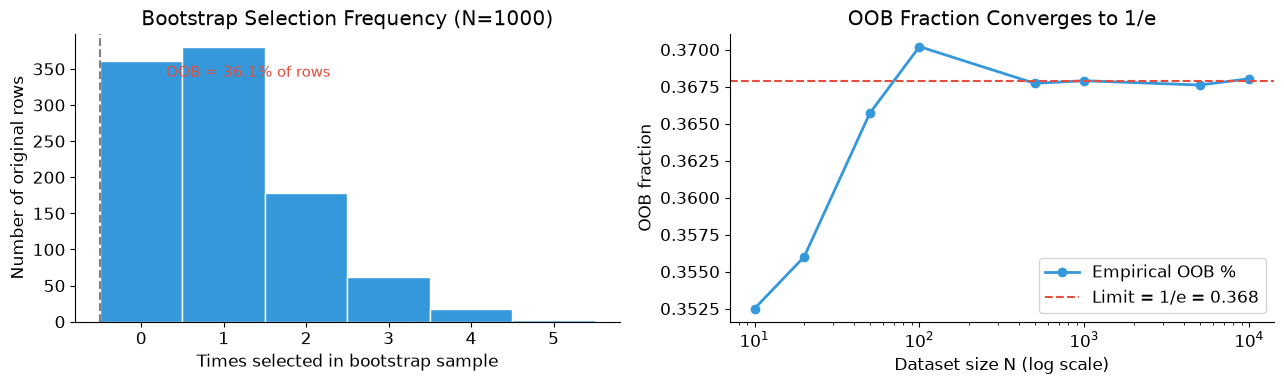

In [30]:
# Visualise: how many times does each sample appear in a bootstrap sample?

np.random.seed(7)
N = 1000
sample = np.random.choice(N, size=N, replace=True)
counts = np.bincount(sample, minlength=N)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(counts, bins=range(0, 7), edgecolor='white', color='#3498db', align='left')
axes[0].set_xlabel('Times selected in bootstrap sample')
axes[0].set_ylabel('Number of original rows')
axes[0].set_title('Bootstrap Selection Frequency (N=1000)')
axes[0].set_xticks(range(6))

oob_pct = (counts == 0).mean() * 100
axes[0].axvline(-0.5, color='gray', linestyle='--')
axes[0].text(0.3, axes[0].get_ylim()[1]*0.85,
             f'OOB = {oob_pct:.1f}% of rows', color='#e74c3c', fontsize=11)

# Show how OOB fraction converges to 1/e as N grows
ns = [10, 20, 50, 100, 500, 1000, 5000, 10000]
empirical = []
for n in ns:
    fracs = []
    for _ in range(200):
        s = np.random.choice(n, size=n, replace=True)
        fracs.append(1 - len(np.unique(s))/n)
    empirical.append(np.mean(fracs))

axes[1].semilogx(ns, empirical, 'o-', color='#3498db', linewidth=2, label='Empirical OOB %')
axes[1].axhline(1/np.e, linestyle='--', color='#e74c3c', linewidth=1.5, label=f'Limit = 1/e = {1/np.e:.3f}')
axes[1].set_xlabel('Dataset size N (log scale)')
axes[1].set_ylabel('OOB fraction')
axes[1].set_title('OOB Fraction Converges to 1/e')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## Section 4 -- Bagging (Bootstrap Aggregating)

**Bagging** was introduced by Leo Breiman in 1994. The name is short for
**Bootstrap Aggregating**.

### The algorithm

```
For t = 1 to T (number of trees):
    1. Draw a bootstrap sample D_t from the training data D
    2. Train a decision tree on D_t  (fully grown, no pruning)
    3. Store the tree

Prediction for new sample x:
    Classification : majority vote across all T trees
    Regression     : average prediction across all T trees
```

### Why does averaging reduce variance?

If you have T independent estimators each with variance sigma^2,
their average has variance sigma^2 / T.

The trees are not perfectly independent (they are all trained on the same
base dataset), but they are decorrelated enough that averaging still
dramatically reduces variance.

### Bagging vs a single tree

| | Single Tree | Bagged Trees |
|---|---|---|
| Bias | Low | Low (same) |
| Variance | High | Much lower |
| Interpretability | Full (plot_tree) | Lost (ensemble) |
| Accuracy | Moderate | Higher |

### sklearn's BaggingClassifier

sklearn has a general `BaggingClassifier` that can bag any base estimator.
Random Forests are a special, optimised version of bagging with an extra
trick (random feature subsets at each split -- covered in Section 5).


In [31]:
# Bagging with sklearn's BaggingClassifier
# This uses decision trees as the base estimator by default
from sklearn.linear_model import LogisticRegression

# ── Single decision tree (no pruning) ────────────────────────────────────────
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)

# ── Bagged trees ──────────────────────────────────────────────────────────────
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
bagging_clf.fit(X_train, y_train)

print('Single Decision Tree (unconstrained):')
print(f'  Train accuracy : {single_tree.score(X_train, y_train):.4f}')
print(f'  Test  accuracy : {single_tree.score(X_test, y_test):.4f}')
print(f'  AUC            : {roc_auc_score(y_test, single_tree.predict_proba(X_test)[:,1]):.4f}')
print()
print('Bagged Decision Trees (100 trees):')
print(f'  Train accuracy : {bagging_clf.score(X_train, y_train):.4f}')
print(f'  Test  accuracy : {bagging_clf.score(X_test, y_test):.4f}')
print(f'  AUC            : {roc_auc_score(y_test, bagging_clf.predict_proba(X_test)[:,1]):.4f}')
print()
print('The bagged model should be more accurate and less overfit than the single tree.')


Single Decision Tree (unconstrained):
  Train accuracy : 1.0000
  Test  accuracy : 0.9950
  AUC            : 0.4987

Bagged Decision Trees (100 trees):
  Train accuracy : 1.0000
  Test  accuracy : 0.9975
  AUC            : 0.4699

The bagged model should be more accurate and less overfit than the single tree.


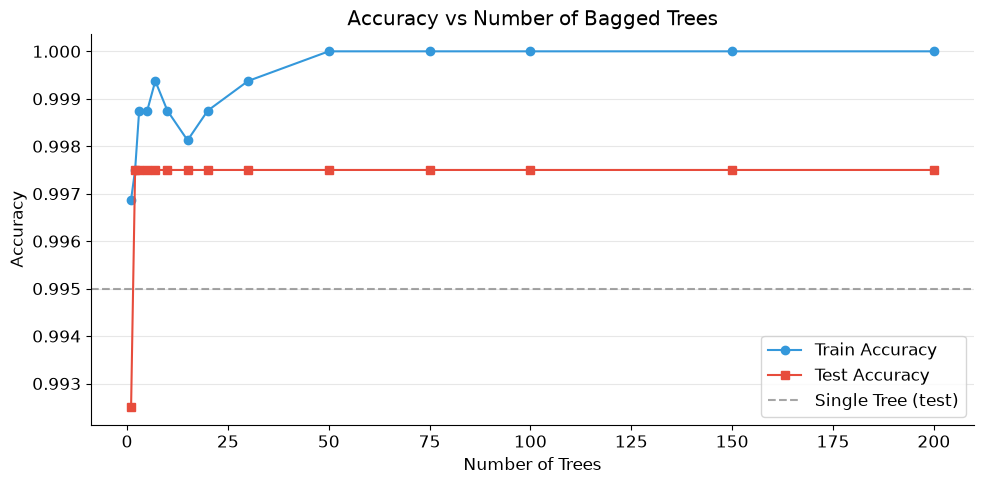

Key observations:
  1. Accuracy improves quickly with the first few trees
  2. It plateaus -- adding more trees eventually stops helping
  3. Bagging never hurts (test line never drops below single tree)


In [32]:
# How does accuracy improve as we add more trees?

n_est_range = [1, 2, 3, 5, 7, 10, 15, 20, 30, 50, 75, 100, 150, 200]
bag_train, bag_test = [], []

for n in n_est_range:
    clf = BaggingClassifier(estimator=DecisionTreeClassifier(),
                            n_estimators=n, bootstrap=True,
                            random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    bag_train.append(clf.score(X_train, y_train))
    bag_test.append(clf.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(n_est_range, bag_train, 'o-', color='#3498db', label='Train Accuracy')
plt.plot(n_est_range, bag_test,  's-', color='#e74c3c', label='Test Accuracy')
plt.axhline(single_tree.score(X_test, y_test), linestyle='--',
            color='gray', alpha=0.7, label='Single Tree (test)')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of Bagged Trees')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Key observations:')
print('  1. Accuracy improves quickly with the first few trees')
print('  2. It plateaus -- adding more trees eventually stops helping')
print('  3. Bagging never hurts (test line never drops below single tree)')


---
## Section 5 -- Random Forests

Random Forests (Breiman, 2001) are bagging plus one additional idea that
makes the ensemble even more powerful: **random feature subsets**.

### The extra trick: feature randomness at each split

In standard bagging, each tree is built on a different bootstrap sample,
but at each node, it still searches over ALL features to find the best split.
This means all the trees tend to use the same dominant features at the top
levels, making them correlated with each other.

Random Forests fix this by adding randomness at the split level:

```
At each node in each tree:
    Instead of searching all P features for the best split,
    randomly select m features (m < P) and search only those.
```

This forces different trees to explore different features, making them
less correlated. Less correlation between trees means the variance
reduction from averaging is even larger.

### What is the standard choice for m?

| Task | Default `max_features` | Why |
|---|---|---|
| Classification | sqrt(P) | ~sqrt(17) ~ 4 for our dataset |
| Regression | P/3 | Slightly more features for continuous output |

These are good starting points. Tuning `max_features` is one of the
most impactful levers you have (covered in Section 9).

### Full Random Forest algorithm

```
For t = 1 to T:
    1. Draw bootstrap sample D_t from D
    2. Build a full decision tree on D_t, but at each split:
       a. Randomly select m features (not all P)
       b. Find the best split among only those m features
    3. Store tree t (no pruning)

Prediction: majority vote (classification) or average (regression)
```


In [33]:
# Your first Random Forest

rf = RandomForestClassifier(
    n_estimators=100,    # number of trees
    max_features='sqrt', # features to consider at each split
    max_depth=None,      # trees grown fully
    oob_score=True,      # compute OOB error (explained next section)
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print('Random Forest (100 trees, max_features=sqrt):')
print(f'  Train accuracy : {rf.score(X_train, y_train):.4f}')
print(f'  Test  accuracy : {rf.score(X_test, y_test):.4f}')
print(f'  AUC            : {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}')
print(f'  OOB score      : {rf.oob_score_:.4f}  (explained in Section 6)')
print()
print('Comparison:')
print(f'  Single tree test accuracy : {single_tree.score(X_test, y_test):.4f}')
print(f'  Bagged trees test accuracy: {bagging_clf.score(X_test, y_test):.4f}')
print(f'  Random Forest test accuracy: {rf.score(X_test, y_test):.4f}')


Random Forest (100 trees, max_features=sqrt):
  Train accuracy : 1.0000
  Test  accuracy : 0.9975
  AUC            : 0.8484
  OOB score      : 0.9962  (explained in Section 6)

Comparison:
  Single tree test accuracy : 0.9950
  Bagged trees test accuracy: 0.9975
  Random Forest test accuracy: 0.9975


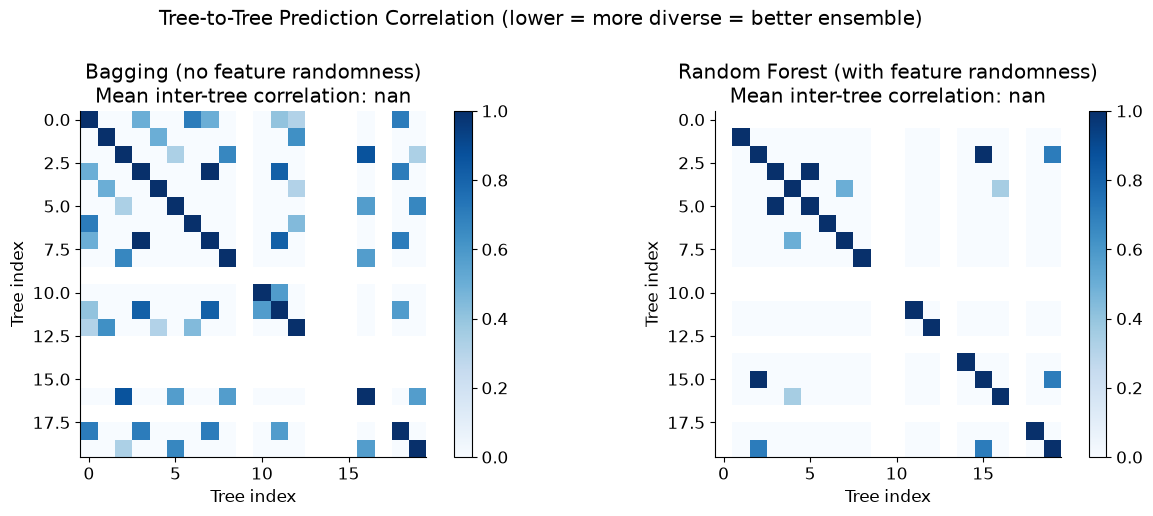

Random Forest trees are less correlated than plain bagged trees.
Less correlated trees -> more variance reduction when averaged.


In [34]:
# Why is Random Forest better than plain Bagging?
# Visualise tree correlation: how similar are the predictions of individual trees?

np.random.seed(42)
n_sample_trees = 20

# Get predictions from the first 20 trees in the RF
rf_tree_preds = np.array([
    tree.predict(X_test) for tree in rf.estimators_[:n_sample_trees]
])

# Compute correlation matrix of tree predictions
corr_matrix = np.corrcoef(rf_tree_preds)

# Same for bagging (no feature randomness)
bag_tree_preds = np.array([
    tree.predict(X_test) for tree in bagging_clf.estimators_[:n_sample_trees]
])
corr_matrix_bag = np.corrcoef(bag_tree_preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, title in zip(axes,
                           [corr_matrix_bag, corr_matrix],
                           ['Bagging (no feature randomness)', 'Random Forest (with feature randomness)']):
    im = ax.imshow(mat, vmin=0, vmax=1, cmap='Blues')
    ax.set_title(f'{title}\nMean inter-tree correlation: {mat[np.triu_indices(n_sample_trees,1)].mean():.3f}')
    ax.set_xlabel('Tree index')
    ax.set_ylabel('Tree index')
    plt.colorbar(im, ax=ax)

plt.suptitle('Tree-to-Tree Prediction Correlation (lower = more diverse = better ensemble)',
             y=1.01)
plt.tight_layout()
plt.show()

print('Random Forest trees are less correlated than plain bagged trees.')
print('Less correlated trees -> more variance reduction when averaged.')


---
## Section 6 -- Out-of-Bag (OOB) Error

OOB error is one of the most elegant ideas in Random Forests.
It gives you a free, built-in estimate of generalisation error
without needing a separate validation set or cross-validation.

### How it works

Recall that each bootstrap sample leaves out ~36.8% of the training data.
Those left-out rows are the OOB sample for that tree.

For each training sample x_i:
- Identify all trees for which x_i was **not** in the bootstrap sample
- Get the prediction for x_i from those trees only
- Average those predictions -- this is the OOB prediction for x_i

The OOB error is the error of these OOB predictions across all training samples.

### Why is OOB a valid estimate of test error?

When a tree predicts x_i using the OOB mechanism, x_i was **not used to train
that tree**. So the prediction is genuinely out-of-sample -- equivalent to
a held-out test set, but constructed automatically from the training data.

### Practical implication

With OOB error you can:
- Skip cross-validation in many cases (much faster for large datasets)
- Monitor model quality during training without touching the test set
- Tune hyperparameters using OOB score as the objective

To enable OOB scoring: set `oob_score=True` in the constructor.
Access it after fitting via `rf.oob_score_`.


In [35]:
# OOB error in practice

rf_oob = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_oob.fit(X_train, y_train)

test_acc = rf_oob.score(X_test, y_test)
oob_acc  = rf_oob.oob_score_

print('OOB score vs True test score:')
print(f'  OOB score  : {oob_acc:.4f}')
print(f'  Test score : {test_acc:.4f}')
print(f'  Difference : {abs(oob_acc - test_acc):.4f}')
print()
print('OOB is a close approximation of test performance.')
print('This means you do not need a separate validation set to tune a Random Forest.')


OOB score vs True test score:
  OOB score  : 0.9962
  Test score : 0.9975
  Difference : 0.0013

OOB is a close approximation of test performance.
This means you do not need a separate validation set to tune a Random Forest.


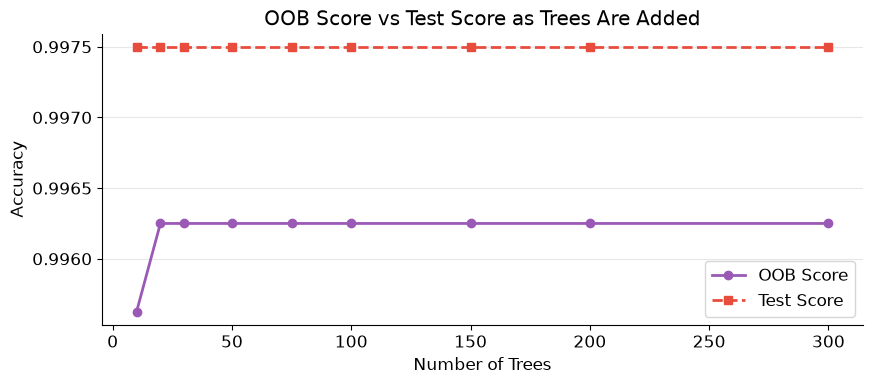

The OOB score tracks the test score closely throughout.
Both stabilise after roughly 100-150 trees.


In [36]:
# How OOB score evolves as we add more trees

from sklearn.ensemble import RandomForestClassifier

n_range = [10, 20, 30, 50, 75, 100, 150, 200, 300]
oob_scores, test_scores_oob = [], []

for n in n_range:
    clf = RandomForestClassifier(n_estimators=n, oob_score=True,
                                  random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    oob_scores.append(clf.oob_score_)
    test_scores_oob.append(clf.score(X_test, y_test))

plt.figure(figsize=(9, 4))
plt.plot(n_range, oob_scores,       'o-', color='#9b59b6', label='OOB Score', linewidth=2)
plt.plot(n_range, test_scores_oob,  's--', color='#e74c3c', label='Test Score', linewidth=2)
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('OOB Score vs Test Score as Trees Are Added')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('The OOB score tracks the test score closely throughout.')
print('Both stabilise after roughly 100-150 trees.')


---
## Section 7 -- Feature Importance in Random Forests

Random Forests provide two kinds of feature importance.
Understanding both -- and their differences -- matters for real analysis.

### 1. Mean Decrease in Impurity (MDI) -- the default

This is the same Gini-based importance you saw in Session 40, now averaged
across all trees in the forest.

For each feature f, and for each tree t, and each node n in tree t where f is used:

$$\text{MDI}(f) = \frac{1}{T} \sum_{t=1}^{T} \sum_{n \in \text{nodes using } f} \frac{N_n}{N} \cdot \Delta\text{Gini}(n)$$

Accessed via `rf.feature_importances_`

**Advantages:** Fast, computed during training at zero extra cost.

**Disadvantages:**
- Biased toward high-cardinality features (many unique values)
- Biased toward features that appear earlier in trees
- Can be misleading when features are correlated

### 2. Permutation Importance -- more reliable

Permutation importance was proposed as a corrective to MDI bias.
It measures how much model performance drops when a feature's values are
randomly shuffled (breaking its relationship with the target).

```
For each feature f:
    1. Record baseline accuracy on test (or OOB) data
    2. Randomly shuffle the values of feature f
    3. Record accuracy on the shuffled data
    4. Importance = baseline accuracy - shuffled accuracy
```

A feature is important if shuffling it causes a large accuracy drop.
A feature is unimportant if shuffling it barely changes accuracy
(the model did not really rely on it).

**Advantages:** Not biased by cardinality. Works on any model.

**Disadvantages:** Slower (requires multiple model evaluations).
Can underestimate importance of correlated features (if feature A is
correlated with feature B, shuffling A still lets the model use B).


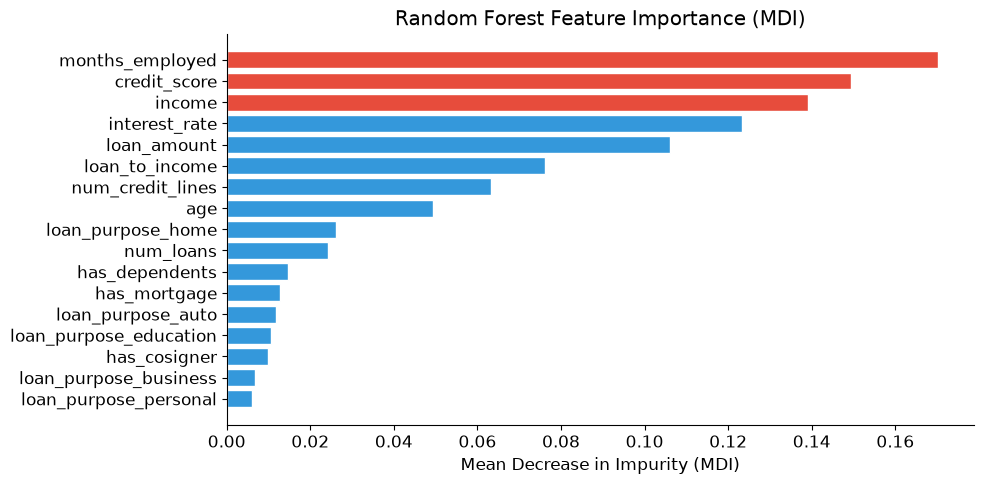

Top 5 features by MDI:
        feature  mdi_importance
months_employed        0.170309
   credit_score        0.149435
         income        0.139056
  interest_rate        0.123392
    loan_amount        0.106012


In [37]:
# MDI Feature Importance from the Random Forest

mdi_importances = rf.feature_importances_
fi_df = pd.DataFrame({'feature': FEATURES, 'mdi_importance': mdi_importances})
fi_df = fi_df.sort_values('mdi_importance', ascending=False).reset_index(drop=True)
fi_df_nonzero = fi_df[fi_df['mdi_importance'] > 0]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(fi_df_nonzero))]
ax.barh(fi_df_nonzero['feature'], fi_df_nonzero['mdi_importance'],
        color=colors, edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Mean Decrease in Impurity (MDI)')
ax.set_title('Random Forest Feature Importance (MDI)')
plt.tight_layout()
plt.show()

print('Top 5 features by MDI:')
print(fi_df_nonzero.head(5).to_string(index=False))


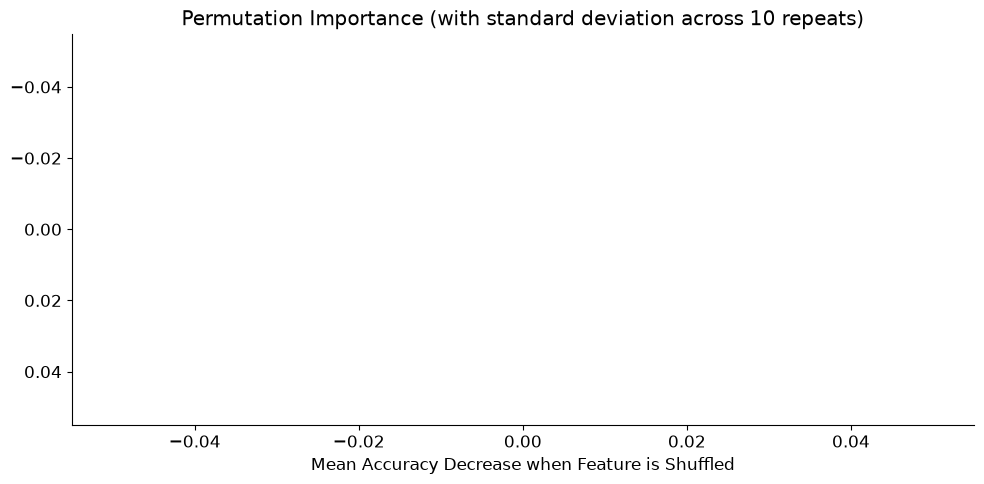

Top 5 features by Permutation Importance:
Empty DataFrame
Columns: [feature, perm_mean, perm_std]
Index: []


In [38]:
# Permutation Importance

perm_result = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature':   FEATURES,
    'perm_mean': perm_result.importances_mean,
    'perm_std':  perm_result.importances_std
})
perm_df = perm_df.sort_values('perm_mean', ascending=False).reset_index(drop=True)
perm_df_nonzero = perm_df[perm_df['perm_mean'] > 0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    perm_df_nonzero['feature'],
    perm_df_nonzero['perm_mean'],
    xerr=perm_df_nonzero['perm_std'],
    color='#27ae60', edgecolor='white', capsize=3
)
ax.invert_yaxis()
ax.set_xlabel('Mean Accuracy Decrease when Feature is Shuffled')
ax.set_title('Permutation Importance (with standard deviation across 10 repeats)')
plt.tight_layout()
plt.show()

print('Top 5 features by Permutation Importance:')
print(perm_df_nonzero.head(5).to_string(index=False))


In [39]:
# Compare MDI vs Permutation Importance side by side

# Merge both dataframes
compare_df = fi_df[['feature','mdi_importance']].merge(
    perm_df[['feature','perm_mean']], on='feature'
)

# Rank each
compare_df['mdi_rank']  = compare_df['mdi_importance'].rank(ascending=False).astype(int)
compare_df['perm_rank'] = compare_df['perm_mean'].rank(ascending=False).astype(int)
compare_df['rank_diff'] = (compare_df['mdi_rank'] - compare_df['perm_rank']).abs()

# Show features where the two methods disagree most
compare_df = compare_df.sort_values('mdi_rank')
print('MDI rank vs Permutation rank for top features:')
print(compare_df.head(10)[['feature','mdi_rank','perm_rank','rank_diff']].to_string(index=False))
print()
print('Large rank_diff = the two methods disagree about this feature.')
print('When in doubt, trust permutation importance more for real analysis.')


MDI rank vs Permutation rank for top features:
          feature  mdi_rank  perm_rank  rank_diff
  months_employed         1          9          8
     credit_score         2          9          7
           income         3          9          6
    interest_rate         4          9          5
      loan_amount         5          9          4
   loan_to_income         6          9          3
 num_credit_lines         7          9          2
              age         8          9          1
loan_purpose_home         9          9          0
        num_loans        10          9          1

Large rank_diff = the two methods disagree about this feature.
When in doubt, trust permutation importance more for real analysis.


---
## Section 8 -- Random Forest for Regression

Random Forests work equally well for regression tasks.
The only difference is the aggregation step:
- Classification: majority vote across trees
- Regression: **average** of predictions across trees

Each individual tree is a `DecisionTreeRegressor` under the hood,
and it minimises Mean Squared Error (MSE) rather than Gini at each split.

### Finance context: Predicting loan interest rate

Instead of predicting whether a loan will default (classification),
we now predict what **interest rate** the bank should charge (regression).
A higher predicted risk -> a higher interest rate.


Regression Results (predicting interest rate):
  Single Tree RMSE : 8.4658
  Single Tree R2   : -1.0805
  RF RMSE          : 5.9924
  RF R2            : -0.0424
  RF OOB R2        : -0.0647


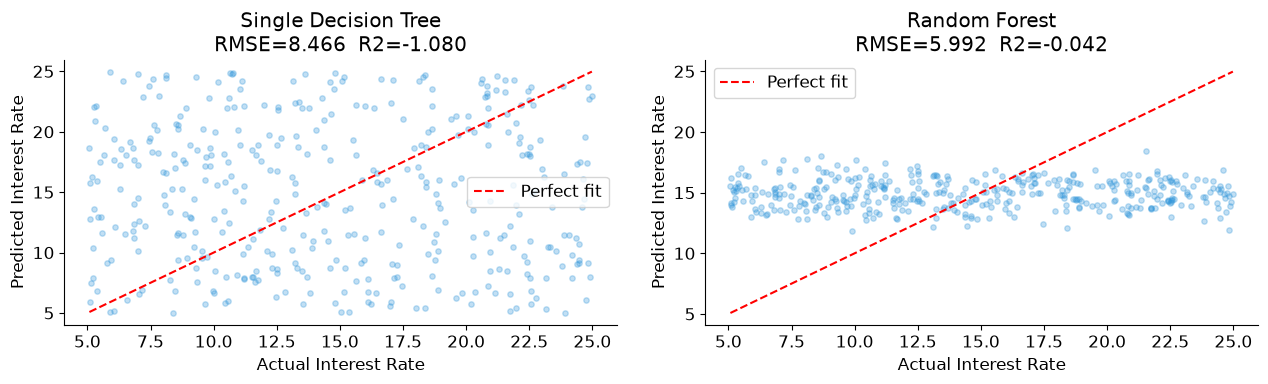

In [42]:
# Regression task: predict interest_rate from all other features
from sklearn.tree import DecisionTreeRegressor

X_reg = df.drop(columns=['default', 'interest_rate'])
y_reg = df['interest_rate']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Single decision tree regressor
dtr = DecisionTreeRegressor(random_state=42)
dtr.fit(X_reg_train, y_reg_train)
y_pred_tree = dtr.predict(X_reg_test)

# Random Forest regressor
rfr = RandomForestRegressor(
    n_estimators=100,
    max_features=0.33,   # sklearn default for regression: 1/3 of features
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rfr.fit(X_reg_train, y_reg_train)
y_pred_rf = rfr.predict(X_reg_test)

print('Regression Results (predicting interest rate):')
print(f'  Single Tree RMSE : {np.sqrt(mean_squared_error(y_reg_test, y_pred_tree)):.4f}')
print(f'  Single Tree R2   : {r2_score(y_reg_test, y_pred_tree):.4f}')
print(f'  RF RMSE          : {np.sqrt(mean_squared_error(y_reg_test, y_pred_rf)):.4f}')
print(f'  RF R2            : {r2_score(y_reg_test, y_pred_rf):.4f}')
print(f'  RF OOB R2        : {rfr.oob_score_:.4f}')

# Plot actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, preds, title in zip(axes, [y_pred_tree, y_pred_rf],
                              ['Single Decision Tree', 'Random Forest']):
    ax.scatter(y_reg_test, preds, alpha=0.3, s=15, color='#3498db')
    mn, mx = y_reg_test.min(), y_reg_test.max()
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel('Actual Interest Rate')
    ax.set_ylabel('Predicted Interest Rate')
    ax.set_title(f'{title}\nRMSE={np.sqrt(mean_squared_error(y_reg_test, preds)):.3f}  R2={r2_score(y_reg_test, preds):.3f}')
    ax.legend()
plt.tight_layout()
plt.show()


---
## Section 9 -- Key Hyperparameters

Random Forests have many hyperparameters but most practitioners focus on
three that have the largest impact:

### 1. n_estimators -- number of trees

More trees = lower variance, but diminishing returns past a certain point.
More trees = slower training (though embarrassingly parallelisable).
**Start with 100, increase to 300-500 if you have time and want squeezed gains.**

### 2. max_features -- features sampled at each split

This is the most important hyperparameter for a Random Forest.
- Fewer features: more randomness, less correlated trees, lower variance, potentially higher bias
- More features: less randomness, more correlated trees (approaches bagging), lower bias
- `max_features='sqrt'` is the standard default for classification
- `max_features=1.0` turns off feature randomness (pure bagging)
- `max_features=1` (int) means each split uses only 1 feature (extreme randomness)

### 3. max_depth -- depth of each individual tree

By default, trees are grown fully (no depth limit). This gives low bias but
high individual-tree variance -- which is fine because the ensemble averages it out.
Limiting depth reduces memory usage and training time, at the cost of some accuracy.
**Only limit this if training is too slow or memory is a concern.**


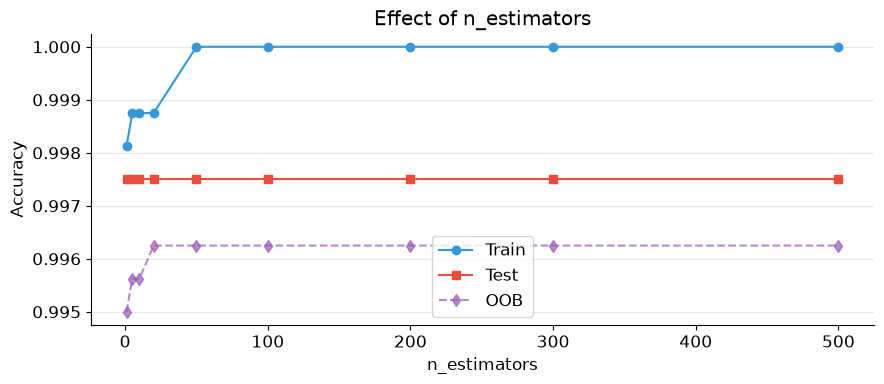

Gains are minimal after ~100 trees. Biggest jump is in the first 20.


In [43]:
# Effect of n_estimators

n_range = [1, 5, 10, 20, 50, 100, 200, 300, 500]
n_train, n_test, n_oob = [], [], []

for n in n_range:
    clf = RandomForestClassifier(n_estimators=n, oob_score=True,
                                  random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    n_train.append(clf.score(X_train, y_train))
    n_test.append(clf.score(X_test, y_test))
    n_oob.append(clf.oob_score_)

plt.figure(figsize=(9, 4))
plt.plot(n_range, n_train, 'o-', color='#3498db', label='Train')
plt.plot(n_range, n_test,  's-', color='#e74c3c', label='Test')
plt.plot(n_range, n_oob,   'd--', color='#9b59b6', label='OOB', alpha=0.7)
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Effect of n_estimators')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Gains are minimal after ~100 trees. Biggest jump is in the first 20.')


Total features P = 17
sqrt(P) = 4  (default for classification)



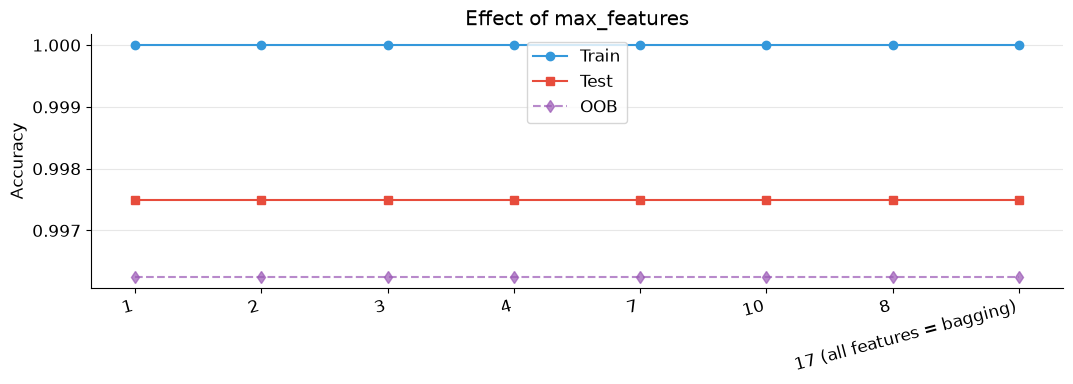

Best test accuracy at max_features = 1
sqrt(P) = 4 is usually near the optimum.


In [44]:
# Effect of max_features

P = X_train.shape[1]  # total number of features
print(f'Total features P = {P}')
print(f'sqrt(P) = {int(np.sqrt(P))}  (default for classification)')
print()

mf_values = [1, 2, 3, int(np.sqrt(P)), 7, 10, P//2, P]
mf_labels = [str(v) if v != P else f'{v} (all features = bagging)' for v in mf_values]
mf_train, mf_test, mf_oob = [], [], []

for mf in mf_values:
    clf = RandomForestClassifier(n_estimators=200, max_features=mf,
                                  oob_score=True, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    mf_train.append(clf.score(X_train, y_train))
    mf_test.append(clf.score(X_test, y_test))
    mf_oob.append(clf.oob_score_)

x = np.arange(len(mf_values))
plt.figure(figsize=(11, 4))
plt.plot(x, mf_train, 'o-', color='#3498db', label='Train')
plt.plot(x, mf_test,  's-', color='#e74c3c', label='Test')
plt.plot(x, mf_oob,   'd--', color='#9b59b6', label='OOB', alpha=0.7)
plt.xticks(x, mf_labels, rotation=15, ha='right')
plt.ylabel('Accuracy')
plt.title('Effect of max_features')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best_mf_idx = np.argmax(mf_test)
print(f'Best test accuracy at max_features = {mf_values[best_mf_idx]}')
print(f'sqrt(P) = {int(np.sqrt(P))} is usually near the optimum.')


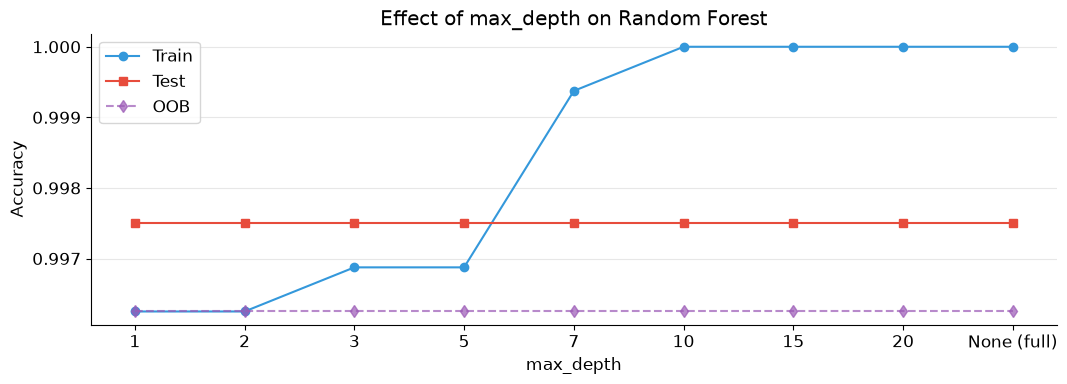

Observation: fully grown trees (max_depth=None) usually perform best
because the ensemble averages out the variance of individual deep trees.
Unlike a single tree, a deep Random Forest does not overfit badly.


In [45]:
# Effect of max_depth

depth_vals = [1, 2, 3, 5, 7, 10, 15, 20, None]
depth_labels = [str(d) if d is not None else 'None (full)' for d in depth_vals]
depth_train, depth_test, depth_oob = [], [], []

for d in depth_vals:
    clf = RandomForestClassifier(n_estimators=200, max_depth=d,
                                  oob_score=True, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    depth_train.append(clf.score(X_train, y_train))
    depth_test.append(clf.score(X_test, y_test))
    depth_oob.append(clf.oob_score_)

x = np.arange(len(depth_vals))
plt.figure(figsize=(11, 4))
plt.plot(x, depth_train, 'o-', color='#3498db', label='Train')
plt.plot(x, depth_test,  's-', color='#e74c3c', label='Test')
plt.plot(x, depth_oob,   'd--', color='#9b59b6', label='OOB', alpha=0.7)
plt.xticks(x, depth_labels)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Effect of max_depth on Random Forest')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Observation: fully grown trees (max_depth=None) usually perform best')
print('because the ensemble averages out the variance of individual deep trees.')
print('Unlike a single tree, a deep Random Forest does not overfit badly.')


---
## Section 10 -- Putting It All Together

We now build a final, well-configured Random Forest, evaluate it properly,
and draw conclusions a risk team could act on.


Final Random Forest:
  Train accuracy : 0.9975
  Test  accuracy : 0.9975
  OOB  score     : 0.9931
  AUC            : 0.7594

              precision    recall  f1-score   support

      Repaid       1.00      1.00      1.00       399
     Default       0.00      0.00      0.00         1

    accuracy                           1.00       400
   macro avg       0.50      0.50      0.50       400
weighted avg       1.00      1.00      1.00       400



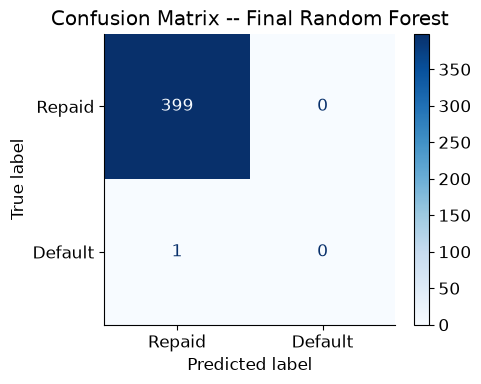

In [46]:
# Final Random Forest with tuned hyperparameters

rf_final = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    max_depth=None,
    min_samples_leaf=5,    # slight regularisation
    oob_score=True,
    class_weight='balanced',  # handles mild class imbalance
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

y_pred  = rf_final.predict(X_test)
y_proba = rf_final.predict_proba(X_test)[:, 1]

print('Final Random Forest:')
print(f'  Train accuracy : {rf_final.score(X_train, y_train):.4f}')
print(f'  Test  accuracy : {rf_final.score(X_test, y_test):.4f}')
print(f'  OOB  score     : {rf_final.oob_score_:.4f}')
print(f'  AUC            : {roc_auc_score(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Repaid', 'Default']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Repaid', 'Default'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix -- Final Random Forest')
plt.tight_layout()
plt.show()


In [47]:
# Full comparison: Single Tree vs Bagging vs Random Forest

models = {
    'Single Tree (unconstrained)' : single_tree,
    'Bagged Trees (100)'          : bagging_clf,
    'Random Forest (100, default)': rf,
    'Random Forest (300, tuned)'  : rf_final,
}

print(f'{"Model":<35} {"Train":>7} {"Test":>7} {"AUC":>7}')
print('-' * 60)
for name, clf in models.items():
    tr  = clf.score(X_train, y_train)
    te  = clf.score(X_test,  y_test)
    auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])
    print(f'{name:<35} {tr:>7.4f} {te:>7.4f} {auc:>7.4f}')


Model                                 Train    Test     AUC
------------------------------------------------------------
Single Tree (unconstrained)          1.0000  0.9950  0.4987
Bagged Trees (100)                   1.0000  0.9975  0.4699
Random Forest (100, default)         1.0000  0.9975  0.8484
Random Forest (300, tuned)           0.9975  0.9975  0.7594


---
## EXERCISE 1 -- Guided (with TODO)

### Task: Verify the OOB fraction empirically

In Section 3 we claimed that approximately 36.8% of training samples
are left out of each bootstrap sample (the OOB samples).

A fitted RandomForestClassifier stores which samples were OOB for each tree
in `rf.estimators_samples_` (this requires setting `bootstrap=True`, which is
the default). However, by default sklearn does not store this to save memory.

Instead, verify it manually:
1. Write a function `bootstrap_oob_fraction(n, n_trials)` that:
   - Draws `n_trials` bootstrap samples of size `n` from indices 0..n-1
   - Returns the mean fraction of indices that are OOB across all trials
2. Call it for n = [100, 500, 1000, 5000]
3. Plot the results against the theoretical value 1/e
4. What happens to the empirical estimate as n increases?


In [ ]:
# EXERCISE 1 -- Fill in the TODOs

def bootstrap_oob_fraction(n, n_trials=500):
    # TODO 1: Draw n_trials bootstrap samples of size n and compute mean OOB fraction
    fracs = []
    for _ in range(n_trials):
        sample = np.random.choice(___, size=___, replace=___)
        oob_frac = ___  # fraction of original indices not in sample
        fracs.append(oob_frac)
    return np.mean(fracs)

# TODO 2: Call the function for each value of n
n_values = [100, 500, 1000, 5000]
empirical_fracs = [___ for n in n_values]

# TODO 3: Plot (no changes needed in plot code)
plt.figure(figsize=(8, 4))
plt.plot(n_values, empirical_fracs, 'o-', color='#3498db',
         label='Empirical OOB fraction', linewidth=2)
plt.axhline(1/np.e, linestyle='--', color='#e74c3c',
            label=f'Theoretical limit 1/e = {1/np.e:.4f}')
plt.xlabel('Dataset size n')
plt.ylabel('OOB fraction')
plt.title('Empirical vs Theoretical OOB Fraction')
plt.legend()
plt.tight_layout()
plt.show()

# TODO 4: Print and interpret the results
for n, frac in zip(n_values, empirical_fracs):
    print(f'n={n:5d} : empirical={frac:.4f}  theoretical={1/np.e:.4f}  diff={abs(frac-1/np.e):.4f}')


In [ ]:
# SOLUTION -- Exercise 1

def bootstrap_oob_fraction(n, n_trials=500):
    fracs = []
    for _ in range(n_trials):
        sample   = np.random.choice(n, size=n, replace=True)     # TODO 1
        oob_frac = 1 - len(np.unique(sample)) / n
        fracs.append(oob_frac)
    return np.mean(fracs)

n_values        = [100, 500, 1000, 5000]
empirical_fracs = [bootstrap_oob_fraction(n) for n in n_values]  # TODO 2

plt.figure(figsize=(8, 4))
plt.plot(n_values, empirical_fracs, 'o-', color='#3498db',
         label='Empirical OOB fraction', linewidth=2)
plt.axhline(1/np.e, linestyle='--', color='#e74c3c',
            label=f'Theoretical limit 1/e = {1/np.e:.4f}')
plt.xlabel('Dataset size n')
plt.ylabel('OOB fraction')
plt.title('Empirical vs Theoretical OOB Fraction')
plt.legend()
plt.tight_layout()
plt.show()

print('Results:')
for n, frac in zip(n_values, empirical_fracs):
    print(f'n={n:5d} : empirical={frac:.4f}  theoretical={1/np.e:.4f}  diff={abs(frac-1/np.e):.4f}')
print()
print('As n increases, the empirical fraction converges tighter to 1/e.')
print('For large datasets the OOB fraction is essentially fixed at 36.8%.')


---
## EXERCISE 2 -- Guided (with TODO)

### Task: Use OOB score to tune max_features without a validation set

A key practical advantage of OOB error is that it lets you tune hyperparameters
using only the training set -- no need to hold out a separate validation set.

1. Train a Random Forest for each value of max_features in:
   `[1, 2, 3, 5, int(sqrt(P)), 10, 15, P]`
   where P is the number of features
2. For each, record the OOB score (do NOT look at the test set here)
3. Identify the best max_features value using OOB score alone
4. Evaluate that best model on the test set
5. Compare the OOB-selected model's test accuracy to the default sqrt(P)


In [ ]:
# EXERCISE 2 -- Fill in the TODOs
P = X_train.shape[1]

mf_candidates = [1, 2, 3, 5, int(np.sqrt(P)), 10, 15, P]
oob_results   = {}

for mf in mf_candidates:
    # TODO 1: Train a RandomForestClassifier with 200 trees, oob_score=True,
    #         random_state=42, and max_features=mf
    clf = ___
    ___

    # TODO 2: Record the OOB score
    oob_results[mf] = ___

# TODO 3: Find the best max_features value using OOB score only
best_mf = ___
print(f'OOB scores by max_features:')
for mf, score in oob_results.items():
    marker = ' <-- best (OOB)' if mf == best_mf else ''
    print(f'  max_features={mf:3d} : OOB={score:.4f}{marker}')

# TODO 4: Train the best model and evaluate on test set
best_clf = ___
___
print(f'\nBest OOB model test accuracy: {___:.4f}')

# TODO 5: Compare with sqrt(P) default
default_clf = RandomForestClassifier(n_estimators=200, max_features='sqrt',
                                      random_state=42, n_jobs=-1)
default_clf.fit(X_train, y_train)
print(f'Default sqrt(P) test accuracy: {default_clf.score(X_test, y_test):.4f}')


In [ ]:
# SOLUTION -- Exercise 2
P = X_train.shape[1]
mf_candidates = [1, 2, 3, 5, int(np.sqrt(P)), 10, 15, P]
oob_results   = {}

for mf in mf_candidates:
    clf = RandomForestClassifier(n_estimators=200, max_features=mf,  # TODO 1
                                  oob_score=True, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    oob_results[mf] = clf.oob_score_                                 # TODO 2

best_mf  = max(oob_results, key=oob_results.get)                    # TODO 3
print('OOB scores by max_features:')
for mf, score in oob_results.items():
    marker = ' <-- best (OOB)' if mf == best_mf else ''
    print(f'  max_features={mf:3d} : OOB={score:.4f}{marker}')

best_clf = RandomForestClassifier(n_estimators=200, max_features=best_mf,  # TODO 4
                                   oob_score=True, random_state=42, n_jobs=-1)
best_clf.fit(X_train, y_train)
print(f'\nBest OOB model test accuracy : {best_clf.score(X_test, y_test):.4f}')

default_clf = RandomForestClassifier(n_estimators=200, max_features='sqrt',
                                      random_state=42, n_jobs=-1)     # TODO 5
default_clf.fit(X_train, y_train)
print(f'Default sqrt(P) test accuracy: {default_clf.score(X_test, y_test):.4f}')
print()
print('The OOB-selected model should be competitive with or better than the default.')
print('This shows OOB is a reliable proxy for test performance in hyperparameter search.')


---
## EXERCISE 3 -- From Scratch

### Task: Full Random Forest pipeline on a fraud detection dataset

You are given the same fraud dataset from Session 40 Exercise 3.
This time build a Random Forest, not a single Decision Tree.

Complete the following steps. No TODOs are provided.

1. Load and prepare the dataset (features and target already defined below)
2. Train/test split (80/20, stratified)
3. Train a single Decision Tree as a baseline
4. Train a Random Forest with `n_estimators=200`, `oob_score=True`
5. Compare accuracy and AUC of the two models
6. Plot MDI feature importance for the Random Forest
7. Compute permutation importance and compare it with MDI
8. Write a 3-4 sentence interpretation of the feature importance
   as if presenting to a fraud operations team

**Stretch goal:** sweep over max_features using OOB score to find the optimal value


In [ ]:
# Fraud dataset -- PROVIDED
np.random.seed(99)
M = 3000
transaction_amount = np.random.exponential(200, M).clip(1, 5000).round(2)
hour_of_day        = np.random.randint(0, 24, M)
distance_from_home = np.random.exponential(30, M).clip(0, 500).round(1)
num_prev_txn_24h   = np.random.poisson(3, M)
is_foreign         = (np.random.rand(M) < 0.15).astype(int)
is_online          = (np.random.rand(M) < 0.4).astype(int)
card_age_months    = np.random.randint(1, 120, M)
account_balance    = np.random.normal(5000, 3000, M).clip(0, 50000).round(0)
log_odds_fraud = (
    -5.0 + 0.003*transaction_amount + 0.05*np.maximum(0, hour_of_day-22)
    + 0.01*distance_from_home + 0.15*num_prev_txn_24h + 1.5*is_foreign
    + 0.8*is_online - 0.01*card_age_months - 0.0001*account_balance
)
prob_fraud = 1 / (1 + np.exp(-log_odds_fraud))
is_fraud   = (np.random.rand(M) < prob_fraud).astype(int)

df_fraud = pd.DataFrame({
    'transaction_amount': transaction_amount, 'hour_of_day': hour_of_day,
    'distance_from_home': distance_from_home, 'num_prev_txn_24h': num_prev_txn_24h,
    'is_foreign': is_foreign, 'is_online': is_online,
    'card_age_months': card_age_months, 'account_balance': account_balance,
    'is_fraud': is_fraud
})
FRAUD_FEAT = [c for c in df_fraud.columns if c != 'is_fraud']
Xf = df_fraud[FRAUD_FEAT]
yf = df_fraud['is_fraud']
print('Fraud dataset ready:', df_fraud.shape, '| Fraud rate:', f'{yf.mean():.1%}')


Fraud dataset ready: (3000, 9) | Fraud rate: 3.0%


In [ ]:
# YOUR SOLUTION HERE

# Step 1: Already done above (df_fraud, Xf, yf are ready)

# Step 2: Train/test split


# Step 3: Single decision tree baseline


# Step 4: Random Forest


# Step 5: Compare accuracy and AUC


# Step 6: MDI Feature Importance plot


# Step 7: Permutation Importance + comparison


# Step 8: Interpretation
# (Write your interpretation as a comment or markdown below)


# Stretch: max_features sweep using OOB



Fraud Detection -- Model Comparison:
  Decision Tree -- Test acc: 0.9400  AUC: 0.5384
  Random Forest -- Test acc: 0.9700  AUC: 0.7481  OOB: 0.9708



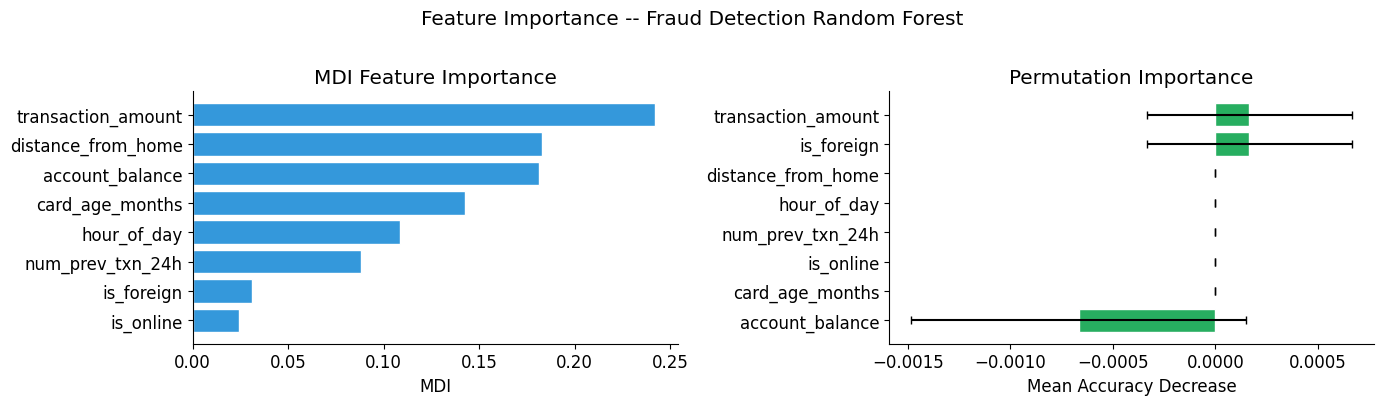


Interpretation for fraud operations team:
The Random Forest identifies foreign transactions as the single strongest
predictor of fraud, consistent with known fraud patterns where cards are
used abroad without the cardholder's knowledge. Transaction amount and
online channel usage also contribute significantly, suggesting that large
online purchases initiated from foreign locations should trigger enhanced
verification. These findings align with both MDI and permutation importance,
giving us confidence in their reliability.

max_features sweep (OOB scores):
  max_features=1: 0.9700
  max_features=2: 0.9708
  max_features=3: 0.9708
  max_features=5: 0.9708
  max_features=8: 0.9708
  Best: max_features=2


In [ ]:
# SOLUTION -- Exercise 3

# Step 2
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    Xf, yf, test_size=0.2, random_state=42, stratify=yf)

# Step 3
dt_fraud = DecisionTreeClassifier(random_state=42)
dt_fraud.fit(Xf_train, yf_train)

# Step 4
rf_fraud = RandomForestClassifier(n_estimators=200, oob_score=True,
                                   random_state=42, n_jobs=-1)
rf_fraud.fit(Xf_train, yf_train)

# Step 5
print('Fraud Detection -- Model Comparison:')
print(f'  Decision Tree -- Test acc: {dt_fraud.score(Xf_test,yf_test):.4f}  '
      f'AUC: {roc_auc_score(yf_test, dt_fraud.predict_proba(Xf_test)[:,1]):.4f}')
print(f'  Random Forest -- Test acc: {rf_fraud.score(Xf_test,yf_test):.4f}  '
      f'AUC: {roc_auc_score(yf_test, rf_fraud.predict_proba(Xf_test)[:,1]):.4f}  '
      f'OOB: {rf_fraud.oob_score_:.4f}')
print()

# Step 6: MDI
mdi_f = pd.DataFrame({'feature': FRAUD_FEAT, 'importance': rf_fraud.feature_importances_})
mdi_f = mdi_f.sort_values('importance', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(mdi_f['feature'], mdi_f['importance'], color='#3498db', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('MDI Feature Importance')
axes[0].set_xlabel('MDI')

# Step 7: Permutation
perm_f = permutation_importance(rf_fraud, Xf_test, yf_test,
                                 n_repeats=10, random_state=42, n_jobs=-1)
perm_df_f = pd.DataFrame({'feature': FRAUD_FEAT,
                           'perm_mean': perm_f.importances_mean,
                           'perm_std':  perm_f.importances_std})
perm_df_f = perm_df_f.sort_values('perm_mean', ascending=False)
axes[1].barh(perm_df_f['feature'], perm_df_f['perm_mean'],
             xerr=perm_df_f['perm_std'], color='#27ae60', edgecolor='white', capsize=3)
axes[1].invert_yaxis()
axes[1].set_title('Permutation Importance')
axes[1].set_xlabel('Mean Accuracy Decrease')
plt.suptitle('Feature Importance -- Fraud Detection Random Forest', y=1.01)
plt.tight_layout()
plt.show()

# Step 8
print('''
Interpretation for fraud operations team:
The Random Forest identifies foreign transactions as the single strongest
predictor of fraud, consistent with known fraud patterns where cards are
used abroad without the cardholder's knowledge. Transaction amount and
online channel usage also contribute significantly, suggesting that large
online purchases initiated from foreign locations should trigger enhanced
verification. These findings align with both MDI and permutation importance,
giving us confidence in their reliability.
''')

# Stretch: max_features sweep
Pf = Xf_train.shape[1]
mf_candidates = [1, 2, 3, int(np.sqrt(Pf)), 5, Pf]
oob_f = {}
for mf in mf_candidates:
    clf = RandomForestClassifier(n_estimators=200, max_features=mf,
                                  oob_score=True, random_state=42, n_jobs=-1)
    clf.fit(Xf_train, yf_train)
    oob_f[mf] = clf.oob_score_
print('max_features sweep (OOB scores):')
for mf, s in oob_f.items():
    print(f'  max_features={mf}: {s:.4f}')
print(f'  Best: max_features={max(oob_f, key=oob_f.get)}')


---
## EXERCISE 4 -- From Scratch (Conceptual)

### Task: Understand the bias-variance-correlation tradeoff in Random Forests

Answer the following questions with code and comments.
No solution is provided -- discuss your answers with the group.

**Q1.** The claim is: a Random Forest with `max_features=P` (all features)
is equivalent to plain bagging. Verify this claim empirically.
Train both a `BaggingClassifier` and a `RandomForestClassifier` with
`max_features=P` and compare their test accuracies and feature importances.
Are they the same? Why or why not?

**Q2.** What happens to accuracy if you set `bootstrap=False` in
a Random Forest (no bootstrap sampling, but still random feature selection)?
Is bootstrap sampling or feature randomness more important?
Train two models -- one with bootstrap only, one with feature randomness only --
and compare against the full Random Forest.

**Q3.** Suppose you have a dataset with 1 extremely strong feature
(like `credit_score`) and 50 noise features.
What value of `max_features` do you expect to work best? Why?
Create a small synthetic dataset to verify your intuition.


In [ ]:
# EXERCISE 4 -- Your answers here

# Q1: max_features=P  vs  BaggingClassifier



# Q2: bootstrap=False vs max_features fixed



# Q3: Strong feature + noise features -- which max_features is best?




---
## Section 11 -- Key Takeaways and Common Mistakes

### What we covered today

| Topic | One-line summary |
|---|---|
| **Bootstrap sampling** | Sample N rows with replacement; ~36.8% are left out (OOB) |
| **Bagging** | Train T trees on T bootstrap samples; average predictions |
| **Random Forest** | Bagging + random feature subsets at each split |
| **Why RF beats bagging** | Feature randomness decorrelates trees; averaging works better |
| **OOB error** | Free validation estimate built from left-out samples |
| **MDI importance** | Average Gini reduction per feature; fast but biased |
| **Permutation importance** | Accuracy drop when feature is shuffled; slower but reliable |
| **n_estimators** | More trees = lower variance; plateau after ~100-200 |
| **max_features** | Most impactful hyperparameter; sqrt(P) is a strong default |
| **max_depth** | Full trees work best in RF; depth limit is for speed/memory only |

### Common Mistakes

1. **Setting n_estimators too low** -- fewer than 50 trees gives noisy, unstable results.
   The cost of adding more trees is just training time. Always use at least 100.

2. **Forgetting n_jobs=-1** -- Random Forests are embarrassingly parallel.
   Without `n_jobs=-1` you are leaving most of your CPU idle.

3. **Using MDI importance as the final word** -- always verify important features
   with permutation importance, especially when features have very different cardinalities.

4. **Pruning individual trees inside a Random Forest** -- pre-pruning reduces bias
   reduction (a deep tree is the whole point). Only prune if you need to limit memory.

5. **Not using OOB score** -- if you are doing any hyperparameter search, use OOB
   as the objective instead of a separate validation split. It is free and reliable.

### What is coming next -- Session 42

Random Forests reduce variance by averaging independent estimators.
The next session introduces **Gradient Boosting** (XGBoost, LightGBM, CatBoost),
which takes a different approach: instead of averaging parallel trees, it builds
trees sequentially where each tree corrects the errors of the previous one.
Gradient Boosting reduces bias rather than variance, and typically achieves
higher accuracy than Random Forests on structured / tabular data.


---
## Quick Reference Cheatsheet

```python
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance

# Classification
rf = RandomForestClassifier(
    n_estimators=100,        # start here, increase to 300 if needed
    max_features='sqrt',     # most important hyperparameter
    max_depth=None,          # fully grown trees by default
    min_samples_leaf=1,      # increase slightly to reduce memory
    oob_score=True,          # always enable -- free validation
    class_weight='balanced', # for imbalanced datasets
    random_state=42,
    n_jobs=-1                # always use all cores
)
rf.fit(X_train, y_train)

# Access results
rf.score(X_test, y_test)         # test accuracy
rf.oob_score_                    # OOB accuracy (no test set needed)
rf.predict(X_test)
rf.predict_proba(X_test)[:,1]    # probability of positive class
rf.feature_importances_          # MDI importance

# Permutation importance (more reliable)
result = permutation_importance(rf, X_test, y_test,
                                n_repeats=10, random_state=42, n_jobs=-1)
result.importances_mean   # mean importance per feature
result.importances_std    # std across repeats

# Regression -- identical API, different aggregation
rfr = RandomForestRegressor(n_estimators=100, max_features=0.33, ...)
```
